# CV Comparison: Gaussian vs Student-t ANP

This notebook mirrors the CV workflow and compares two checkpoints:
- baseline Gaussian decoder likelihood
- Student-t decoder likelihood

It reports aggregate CV metrics and radius-binned empirical coverage.

In [13]:
from pathlib import Path
import math
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.distributions import StudentT

from anp_emulator import Emulator

In [14]:
# Set explicit run directories if you want full control.
RUN_DIR_GAUSSIAN = Path('anp_training_runs/anp_all_profiles_20260323_140601')
RUN_DIR_STUDENTT = Path('anp_training_runs/anp_all_profiles_20260323_144522')  # update when ready

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
CV_PROFILE_DIR = Path('/mnt/home/mlee1/ceph/Profiles_cy_test/')
CV_FIELDS = ['pressure', 'temperature', 'gas_density']
CV_NSAMPLES = 30
CV_MASS_CUT = 1e12
EPS = 1e-30

if not CV_PROFILE_DIR.exists():
    raise FileNotFoundError(f'Profile directory not found: {CV_PROFILE_DIR}')

if not RUN_DIR_GAUSSIAN.exists():
    raise FileNotFoundError(f'Gaussian run directory not found: {RUN_DIR_GAUSSIAN}')
if not RUN_DIR_STUDENTT.exists():
    raise FileNotFoundError(
        f'Student-t run directory not found: {RUN_DIR_STUDENTT}. '
        'Update RUN_DIR_STUDENTT to the new run once it writes a checkpoint.'
    )

In [15]:
def _parse_snapshot_redshifts_text(mapping_text):
    out = {}
    for chunk in str(mapping_text).split(','):
        chunk = chunk.strip()
        if not chunk:
            continue
        snap_str, sep, z_str = chunk.partition(':')
        if sep != ':':
            continue
        out[int(snap_str.strip())] = float(z_str.strip())
    return out


def _resolve_training_snaps_and_redshifts(run_args):
    snaps = []
    if isinstance(run_args.get('resolved_snapnums', None), (list, tuple)):
        snaps = [int(s) for s in run_args['resolved_snapnums']]
    elif isinstance(run_args.get('snapnums', None), (list, tuple)):
        snaps = [int(s) for s in run_args['snapnums']]
    elif run_args.get('snapnum', None) is not None:
        snaps = [int(run_args['snapnum'])]
    snaps = sorted(set(snaps))

    redshift_by_snap = {}
    if isinstance(run_args.get('redshift_by_snap', None), dict):
        redshift_by_snap = {int(k): float(v) for k, v in run_args['redshift_by_snap'].items()}
    elif isinstance(run_args.get('snapshot_redshifts', None), str):
        redshift_by_snap = _parse_snapshot_redshifts_text(run_args['snapshot_redshifts'])

    for s in snaps:
        redshift_by_snap.setdefault(int(s), np.nan)
    return snaps, redshift_by_snap


def _halfwidth_for_sigma_level(level, likelihood_name, student_t_df):
    p_two_sided = math.erf(float(level) / math.sqrt(2.0))
    if str(likelihood_name).lower() != 'student_t':
        return float(level)

    q = 0.5 * (1.0 + p_two_sided)

    # torch.distributions.StudentT.icdf is not implemented in some torch builds.
    # Prefer scipy if available, otherwise use a deterministic Monte Carlo fallback.
    try:
        from scipy.stats import t as scipy_t
        return float(scipy_t.ppf(q, df=float(student_t_df)))
    except Exception:
        rng = np.random.default_rng(12345)
        samples = rng.standard_t(df=float(student_t_df), size=2_000_000)
        return float(np.quantile(samples, q))


EMU_RUNS = {
    'gaussian': Emulator.from_run_dir(RUN_DIR_GAUSSIAN, device=DEVICE),
    'student_t': Emulator.from_run_dir(RUN_DIR_STUDENTT, device=DEVICE),
}

for name, emu in EMU_RUNS.items():
    lk = str(emu.args.get('decoder_likelihood', 'gaussian'))
    df = float(emu.args.get('student_t_df', 5.0))
    snaps, _ = _resolve_training_snaps_and_redshifts(dict(emu.args))
    print(f'{name:10s} | likelihood={lk:10s} | df={df:5.2f} | snaps={snaps}')
    print(f'  run dir: {emu.checkpoint_path.parent}')

gaussian   | likelihood=gaussian   | df= 5.00 | snaps=[44, 60, 74, 90]
  run dir: anp_training_runs/anp_all_profiles_20260323_140601
student_t  | likelihood=student_t  | df= 5.00 | snaps=[44, 60, 74, 90]
  run dir: anp_training_runs/anp_all_profiles_20260323_144522


In [16]:
# Build CV file map from baseline run snapshot set.
run_args_ref = dict(EMU_RUNS['gaussian'].args)
training_snapnums, training_redshift_by_snap = _resolve_training_snaps_and_redshifts(run_args_ref)
if len(training_snapnums) == 0:
    raise RuntimeError('Could not determine training snapshots from Gaussian run args')

cv_file_pattern = re.compile(r'IllustrisTNG_(CV_\d+)_snap(\d+)\.npz$')
cv_tag_to_file_by_snap = {}
for fp in sorted(CV_PROFILE_DIR.glob('IllustrisTNG_CV_*_snap*.npz')):
    m = cv_file_pattern.match(fp.name)
    if m is None:
        continue
    tag = m.group(1)
    snap = int(m.group(2))
    if snap not in training_snapnums:
        continue
    cv_tag_to_file_by_snap.setdefault(snap, {})[tag] = fp

cv_snaps_available = sorted(cv_tag_to_file_by_snap.keys())
if len(cv_snaps_available) == 0:
    raise FileNotFoundError(
        'No CV files found for training snapshots in '
        f'{CV_PROFILE_DIR}. Training snapshots: {training_snapnums}'
    )

# Fiducial theta from 1P file (1P_p1_0).
oneP_param_csv = Path('/mnt/home/mlee1/Sims/IllustrisTNG/L50n512/1P/CosmoAstroSeed_IllustrisTNG_L50n512_1P.txt')
if not oneP_param_csv.exists():
    raise FileNotFoundError(f'1P parameter file not found: {oneP_param_csv}')
oneP_theta_df = pd.read_csv(oneP_param_csv, sep=r'\s+', engine='python')
oneP_theta_df = oneP_theta_df.rename(columns={'#Name': 'tag'})
theta_fid = oneP_theta_df[oneP_theta_df['tag'] == '1P_p1_0'].iloc[0, 1:-1].to_numpy(dtype=np.float32)

print(f'Training snapshots: {training_snapnums}')
print(f'CV snapshots available: {cv_snaps_available}')
print(f'theta_fid shape: {theta_fid.shape}')

Training snapshots: [44, 60, 74, 90]
CV snapshots available: [44, 60, 74, 90]
theta_fid shape: (35,)


In [17]:
# Run both emulators across CV files.
predictions = {name: {} for name in EMU_RUNS}
summary_rows = []

for model_name, emu in EMU_RUNS.items():
    model_preds_by_snap = {}

    for snap in cv_snaps_available:
        z_snap = float(training_redshift_by_snap.get(int(snap), np.nan))
        snap_preds = {}

        for tag, fp in sorted(cv_tag_to_file_by_snap[snap].items()):
            with np.load(fp) as dat:
                masses = np.asarray(dat['M500c'], dtype=np.float64)
                r500c = np.asarray(dat['R500c'], dtype=np.float64)
                radial_bins = np.asarray(dat['radial_bins'], dtype=np.float64)

                true_profiles = {}
                for fld in CV_FIELDS:
                    key = f'{fld}_array'
                    if key not in dat:
                        raise KeyError(f'Missing {key} in {fp.name}')
                    true_profiles[fld] = np.asarray(dat[key], dtype=np.float64)

            n_halo = masses.shape[0]
            n_r = radial_bins.shape[0]
            r_bins_rr500 = (radial_bins[None, :] / np.maximum(r500c[:, None], 1e-12)).astype(np.float32)

            pred = emu.predict(
                theta=theta_fid,
                M=masses.astype(np.float32),
                r_bins=r_bins_rr500,
                field=CV_FIELDS,
                snapnum=int(snap),
                redshift=float(z_snap),
                n_samples=CV_NSAMPLES,
            )

            pred_mu = {fld: np.zeros((n_halo, n_r), dtype=np.float64) for fld in CV_FIELDS}
            pred_sd = {fld: np.zeros((n_halo, n_r), dtype=np.float64) for fld in CV_FIELDS}
            for j, fld in enumerate(pred.field_names):
                pred_mu[fld] = np.asarray(pred.mean[:, :, j], dtype=np.float64)
                pred_sd[fld] = np.asarray(pred.total_std[:, :, j], dtype=np.float64)

            snap_preds[tag] = {
                'file': str(fp),
                'snapnum': int(snap),
                'redshift': float(z_snap),
                'M500c': masses,
                'R500c': r500c,
                'rr500': r_bins_rr500,
                'radial_bins': radial_bins,
                'true_profiles': true_profiles,
                'pred_mu': pred_mu,
                'pred_sd': pred_sd,
            }

            summary_rows.append({
                'model': model_name,
                'snapnum': int(snap),
                'redshift': float(z_snap),
                'tag': tag,
                'n_halos': int(n_halo),
                'n_r': int(n_r),
                'm500c_median': float(np.median(masses)),
            })

        model_preds_by_snap[int(snap)] = snap_preds

    predictions[model_name] = model_preds_by_snap

pred_summary_df = pd.DataFrame(summary_rows).sort_values(['model', 'snapnum', 'tag']).reset_index(drop=True)
display(pred_summary_df.head(20))

,model,snapnum,redshift,tag,n_halos,n_r,m500c_median
0,gaussian,44,2.0,CV_0,40,30,2.919479e+12
1,gaussian,44,2.0,CV_1,32,30,2.885884e+12
2,gaussian,44,2.0,CV_10,31,30,3.255745e+12
3,gaussian,44,2.0,CV_11,30,30,3.048070e+12
4,gaussian,44,2.0,CV_12,35,30,2.813798e+12
5,gaussian,44,2.0,CV_13,29,30,2.996716e+12
6,gaussian,44,2.0,CV_14,44,30,3.074014e+12
7,gaussian,44,2.0,CV_15,40,30,3.013894e+12
8,gaussian,44,2.0,CV_16,32,30,3.547108e+12
9,gaussian,44,2.0,CV_17,29,30,3.442423e+12


In [18]:
# Aggregate metric comparison.
metric_rows = []

for model_name, emu in EMU_RUNS.items():
    likelihood = str(emu.args.get('decoder_likelihood', 'gaussian')).lower()
    student_t_df = float(emu.args.get('student_t_df', 5.0))
    hw_1 = _halfwidth_for_sigma_level(1.0, likelihood, student_t_df)
    hw_2 = _halfwidth_for_sigma_level(2.0, likelihood, student_t_df)

    for fld in CV_FIELDS:
        true_all, pred_all, sd_all = [], [], []

        for snap in sorted(predictions[model_name].keys()):
            for tag in sorted(predictions[model_name][snap].keys()):
                rec = predictions[model_name][snap][tag]
                t = np.asarray(rec['true_profiles'][fld], dtype=np.float64)
                p = np.asarray(rec['pred_mu'][fld], dtype=np.float64)
                s = np.clip(np.asarray(rec['pred_sd'][fld], dtype=np.float64), 1e-30, None)
                true_all.append(t)
                pred_all.append(p)
                sd_all.append(s)

        true_all = np.concatenate([x.reshape(-1) for x in true_all])
        pred_all = np.concatenate([x.reshape(-1) for x in pred_all])
        sd_all = np.concatenate([x.reshape(-1) for x in sd_all])

        err = pred_all - true_all
        rmse = float(np.sqrt(np.mean(err ** 2)))
        mae = float(np.mean(np.abs(err)))

        z = err / sd_all
        if likelihood == 'student_t':
            nll = float(-(StudentT(df=float(student_t_df)).log_prob(torch.tensor(z, dtype=torch.float64)).numpy() - np.log(sd_all)).mean())
        else:
            nll = float((0.5 * z ** 2 + np.log(sd_all) + 0.5 * np.log(2.0 * np.pi)).mean())

        cov1 = float(np.mean(np.abs(err) <= hw_1 * sd_all))
        cov2 = float(np.mean(np.abs(err) <= hw_2 * sd_all))

        pos = (true_all > 0) & (pred_all > 0)
        if np.any(pos):
            med_abs_log10 = float(np.median(np.abs(np.log10(pred_all[pos]) - np.log10(true_all[pos]))))
        else:
            med_abs_log10 = np.nan

        metric_rows.append({
            'model': model_name,
            'likelihood': likelihood,
            'student_t_df': student_t_df,
            'field': fld,
            'rmse': rmse,
            'mae': mae,
            'nll': nll,
            'coverage_1sigma': cov1,
            'coverage_2sigma': cov2,
            'median_abs_log10_resid': med_abs_log10,
        })

metrics_df = pd.DataFrame(metric_rows).sort_values(['field', 'model']).reset_index(drop=True)
display(metrics_df)

pivot_cols = ['rmse', 'mae', 'nll', 'coverage_1sigma', 'coverage_2sigma', 'median_abs_log10_resid']
for fld in CV_FIELDS:
    print(f'\nField: {fld}')
    tdf = metrics_df[metrics_df['field'] == fld][['model'] + pivot_cols].set_index('model')
    display(tdf)

,model,likelihood,student_t_df,field,rmse,mae,nll,coverage_1sigma,coverage_2sigma,median_abs_log10_resid
0,gaussian,gaussian,5.0,gas_density,7.444542e-27,1.620057e-27,-62.532078,0.729382,0.920312,0.165515
1,student_t,student_t,5.0,gas_density,8.771723e-27,2.808257e-27,-62.539866,0.922304,0.985137,0.206245
2,gaussian,gaussian,5.0,pressure,7.265310e-23,7.974255e-24,-29.387183,0.679060,0.890169,0.219295
3,student_t,student_t,5.0,pressure,8.546428e-23,1.015258e-23,-54.300780,0.817480,0.918345,0.271577
4,gaussian,gaussian,5.0,temperature,2.528898e-01,1.277555e-01,0.210784,0.645562,0.884304,0.153912
5,student_t,student_t,5.0,temperature,4.338530e-01,1.869244e-01,-0.359022,0.756778,0.918567,0.199958



Field: pressure


,rmse,mae,nll,coverage_1sigma,coverage_2sigma,median_abs_log10_resid
model,,,,,,
gaussian,7.265310e-23,7.974255e-24,-29.387183,0.67906,0.890169,0.219295
student_t,8.546428e-23,1.015258e-23,-54.300780,0.81748,0.918345,0.271577



Field: temperature


,rmse,mae,nll,coverage_1sigma,coverage_2sigma,median_abs_log10_resid
model,,,,,,
gaussian,0.252890,0.127756,0.210784,0.645562,0.884304,0.153912
student_t,0.433853,0.186924,-0.359022,0.756778,0.918567,0.199958



Field: gas_density


,rmse,mae,nll,coverage_1sigma,coverage_2sigma,median_abs_log10_resid
model,,,,,,
gaussian,7.444542e-27,1.620057e-27,-62.532078,0.729382,0.920312,0.165515
student_t,8.771723e-27,2.808257e-27,-62.539866,0.922304,0.985137,0.206245


,model,field,sigma_level,radius_bin,r_over_r500_lo,r_over_r500_hi,target_coverage,coverage,coverage_minus_target,n_points
0,gaussian,gas_density,1.0,"[0.00, 0.10)",0.0,0.1,0.682689,0.801174,0.118485,39341.0
1,gaussian,gas_density,1.0,"[0.10, 0.20)",0.1,0.2,0.682689,0.663507,-0.019182,31124.0
2,gaussian,gas_density,1.0,"[0.20, 0.40)",0.2,0.4,0.682689,0.630137,-0.052552,30998.0
3,gaussian,gas_density,1.0,"[0.40, 0.80)",0.4,0.8,0.682689,0.694472,0.011783,31097.0
4,gaussian,gas_density,1.0,"[0.80, 1.20)",0.8,1.2,0.682689,0.767796,0.085107,18178.0
...,...,...,...,...,...,...,...,...,...,...
91,student_t,temperature,2.0,"[0.40, 0.80)",0.4,0.8,0.954500,0.945525,-0.008974,31097.0
92,student_t,temperature,2.0,"[0.80, 1.20)",0.8,1.2,0.954500,0.953955,-0.000544,18178.0
93,student_t,temperature,2.0,"[1.20, 2.00)",1.2,2.0,0.954500,0.958704,0.004205,22908.0
94,student_t,temperature,2.0,"[2.00, 4.00)",2.0,4.0,0.954500,0.952252,-0.002248,31059.0


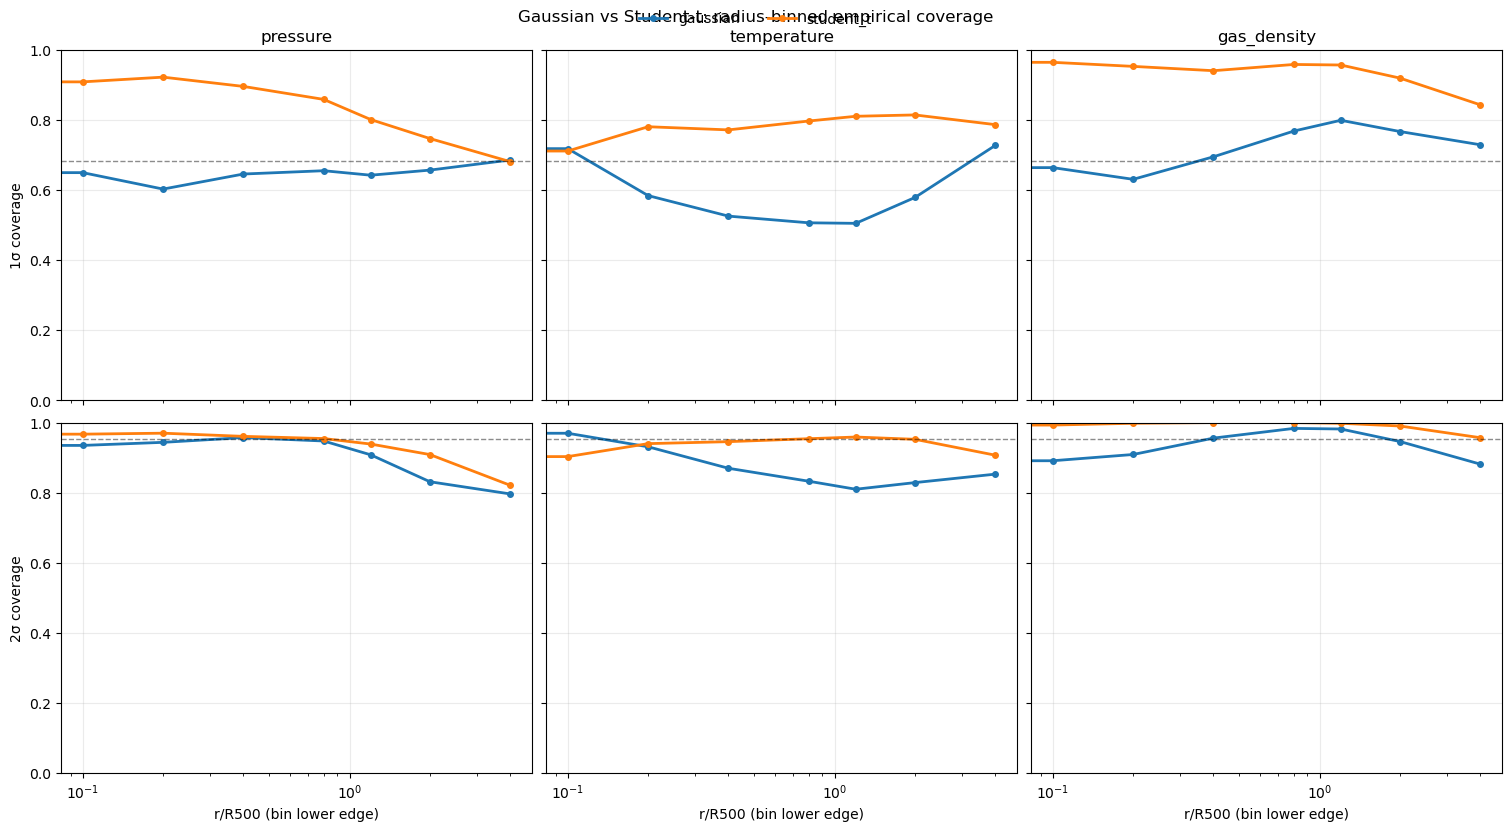

Core-only coverage summary (r/R500 <= 0.4):


,model,field,sigma_level,radius_bin,r_over_r500_lo,r_over_r500_hi,target_coverage,coverage,coverage_minus_target,n_points
0,gaussian,gas_density,1.0,"[0.00, 0.10)",0.0,0.1,0.682689,0.801174,0.118485,39341.0
1,gaussian,gas_density,1.0,"[0.10, 0.20)",0.1,0.2,0.682689,0.663507,-0.019182,31124.0
2,gaussian,gas_density,1.0,"[0.20, 0.40)",0.2,0.4,0.682689,0.630137,-0.052552,30998.0
8,student_t,gas_density,1.0,"[0.00, 0.10)",0.0,0.1,0.682689,0.967922,0.285232,39341.0
9,student_t,gas_density,1.0,"[0.10, 0.20)",0.1,0.2,0.682689,0.963886,0.281197,31124.0
10,student_t,gas_density,1.0,"[0.20, 0.40)",0.2,0.4,0.682689,0.952320,0.269630,30998.0
16,gaussian,gas_density,2.0,"[0.00, 0.10)",0.0,0.1,0.954500,0.912509,-0.041991,39341.0
17,gaussian,gas_density,2.0,"[0.10, 0.20)",0.1,0.2,0.954500,0.891081,-0.063419,31124.0
18,gaussian,gas_density,2.0,"[0.20, 0.40)",0.2,0.4,0.954500,0.908930,-0.045570,30998.0
24,student_t,gas_density,2.0,"[0.00, 0.10)",0.0,0.1,0.954500,0.992171,0.037671,39341.0


In [19]:
# Radius-binned coverage comparison across models.
radius_edges = np.array([0.0, 0.1, 0.2, 0.4, 0.8, 1.2, 2.0, 4.0, np.inf], dtype=np.float64)
sigma_levels = [1.0, 2.0]
rows = []

for model_name, emu in EMU_RUNS.items():
    likelihood = str(emu.args.get('decoder_likelihood', 'gaussian')).lower()
    student_t_df = float(emu.args.get('student_t_df', 5.0))
    halfwidths = {lvl: _halfwidth_for_sigma_level(lvl, likelihood, student_t_df) for lvl in sigma_levels}

    for snap in sorted(predictions[model_name].keys()):
        for tag in sorted(predictions[model_name][snap].keys()):
            rec = predictions[model_name][snap][tag]
            rr = np.asarray(rec['rr500'], dtype=np.float64)

            for fld in CV_FIELDS:
                true_arr = np.asarray(rec['true_profiles'][fld], dtype=np.float64)
                pred_arr = np.asarray(rec['pred_mu'][fld], dtype=np.float64)
                std_arr = np.clip(np.asarray(rec['pred_sd'][fld], dtype=np.float64), 1e-30, None)
                abs_err = np.abs(pred_arr - true_arr)

                for i in range(len(radius_edges) - 1):
                    lo = float(radius_edges[i])
                    hi = float(radius_edges[i + 1])
                    if np.isfinite(hi):
                        m = (rr >= lo) & (rr < hi)
                        bin_label = f'[{lo:.2f}, {hi:.2f})'
                    else:
                        m = (rr >= lo)
                        bin_label = f'>={lo:.2f}'

                    n = int(np.count_nonzero(m))
                    if n == 0:
                        continue

                    for lvl in sigma_levels:
                        hw = float(halfwidths[lvl])
                        hit = abs_err[m] <= (hw * std_arr[m])
                        cov = float(np.mean(hit))
                        target_cov = float(math.erf(float(lvl) / math.sqrt(2.0)))
                        rows.append({
                            'model': model_name,
                            'field': fld,
                            'sigma_level': float(lvl),
                            'target_coverage': target_cov,
                            'radius_bin': bin_label,
                            'r_over_r500_lo': lo,
                            'r_over_r500_hi': hi,
                            'n_points': n,
                            'coverage': cov,
                            'coverage_minus_target': cov - target_cov,
                        })

coverage_df = pd.DataFrame(rows)
if coverage_df.empty:
    raise RuntimeError('No rows built for coverage comparison.')

coverage_summary = (
    coverage_df
    .groupby(['model', 'field', 'sigma_level', 'radius_bin', 'r_over_r500_lo', 'r_over_r500_hi'], as_index=False)
    .apply(lambda g: pd.Series({
        'target_coverage': float(g['target_coverage'].iloc[0]),
        'coverage': float(np.average(g['coverage'], weights=np.clip(g['n_points'], 1, None))),
        'coverage_minus_target': float(np.average(g['coverage_minus_target'], weights=np.clip(g['n_points'], 1, None))),
        'n_points': int(g['n_points'].sum()),
    }))
    .sort_values(['field', 'sigma_level', 'model', 'r_over_r500_lo'])
    .reset_index(drop=True)
)
display(coverage_summary)

# Plot coverage-vs-radius for each field and sigma level.
n_fields = len(CV_FIELDS)
fig, axes = plt.subplots(2, n_fields, figsize=(5.0 * n_fields, 8.0), constrained_layout=True, sharex='col', sharey='row')
if n_fields == 1:
    axes = np.array(axes).reshape(2, 1)

color_map = {'gaussian': 'tab:blue', 'student_t': 'tab:orange'}
for c, fld in enumerate(CV_FIELDS):
    for r, lvl in enumerate([1.0, 2.0]):
        ax = axes[r, c]
        sdf = coverage_summary[(coverage_summary['field'] == fld) & (coverage_summary['sigma_level'] == lvl)]

        for model_name in sorted(sdf['model'].unique()):
            ss = sdf[sdf['model'] == model_name].sort_values('r_over_r500_lo')
            x = ss['r_over_r500_lo'].to_numpy(dtype=np.float64)
            y = ss['coverage'].to_numpy(dtype=np.float64)
            ax.plot(x, y, marker='o', ms=4, lw=2.0, color=color_map.get(model_name, None), label=model_name)

        if not sdf.empty:
            ax.axhline(float(sdf['target_coverage'].iloc[0]), color='k', ls='--', lw=1.0, alpha=0.45)

        ax.set_xscale('log')
        ax.set_ylim(0.0, 1.0)
        ax.grid(True, alpha=0.25)
        if r == 0:
            ax.set_title(fld)
        if c == 0:
            ax.set_ylabel(f'{int(lvl)}σ coverage')
        if r == 1:
            ax.set_xlabel('r/R500 (bin lower edge)')

handles, labels = axes[0, 0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc='upper center', ncol=max(2, len(labels)), frameon=False)
fig.suptitle('Gaussian vs Student-t: radius-binned empirical coverage', y=1.02)
plt.show()

core_table = coverage_summary[coverage_summary['r_over_r500_hi'] <= 0.4].copy()
print('Core-only coverage summary (r/R500 <= 0.4):')
display(core_table)